# Agente Connect-4: MCTS (Monte Carlo Tree Search)
**Fundamentos de Inteligencia Artificial — Universidad de La Sabana 2026.1**

## 1. Configuración del entorno

In [5]:
import sys, os, random, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Asegura que connect4/ sea encontrado
sys.path.insert(0, os.path.abspath('.'))

from connect4.connect_state import ConnectState
from policy import MCTSPolicy, _wins_at, _check_winner

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

np.random.seed(42)
random.seed(42)
print('Entorno listo.')

Entorno listo.


## 2. Utilidades de simulación

In [6]:
def random_act(board):
    return random.choice([c for c in range(7) if board[0, c] == 0])

def play_game(red_fn, yellow_fn):
    s = ConnectState()
    while not s.is_final():
        col = red_fn(s.board) if s.player == -1 else yellow_fn(s.board)
        s = s.transition(int(col))
    return int(s.get_winner())

def run_experiment(agent_factory, opponent_factory, n_games, label):
    """
    Corre n_games partidas como Rojo y n_games como Amarillo.
    Muestra progreso en pantalla.
    Devuelve (wins_red, draws_red, losses_red, wins_yellow, draws_yellow, losses_yellow)
    """
    wr = dr = lr = 0
    wy = dy = ly = 0
    total = n_games * 2
    t0 = time.time()

    print(f'\n  Simulando: {label}')
    print(f'  {total} partidas en total ({n_games} como Rojo + {n_games} como Amarillo)')

    for i in range(n_games):
        ag = agent_factory(); ag.mount()
        op = opponent_factory(); op.mount() if hasattr(op, 'mount') else None
        result = play_game(lambda b, a=ag: a.act(b),
                           lambda b, o=op: o.act(b) if hasattr(o, 'act') else random_act(b))
        if result == -1: wr += 1
        elif result == 0: dr += 1
        else: lr += 1
        done = i + 1
        elapsed = time.time() - t0
        eta = (elapsed / done) * (total - done)
        print(f'  [{done:>3}/{total}] Como Rojo    — V:{wr} E:{dr} D:{lr}  '
              f'(transcurrido: {elapsed:.0f}s  restante: {eta:.0f}s)', end='\r')

    print(f'  [{n_games:>3}/{total}] Como Rojo    — V:{wr} E:{dr} D:{lr}  (listo)          ')

    for i in range(n_games):
        ag = agent_factory(); ag.mount()
        op = opponent_factory(); op.mount() if hasattr(op, 'mount') else None
        result = play_game(lambda b, o=op: o.act(b) if hasattr(o, 'act') else random_act(b),
                           lambda b, a=ag: a.act(b))
        if result == 1: wy += 1
        elif result == 0: dy += 1
        else: ly += 1
        done = n_games + i + 1
        elapsed = time.time() - t0
        eta = (elapsed / done) * (total - done)
        print(f'  [{done:>3}/{total}] Como Amarillo — V:{wy} E:{dy} D:{ly}  '
              f'(transcurrido: {elapsed:.0f}s  restante: {eta:.0f}s)', end='\r')

    elapsed = time.time() - t0
    print(f'  [{total:>3}/{total}] Como Amarillo — V:{wy} E:{dy} D:{ly}  (listo)          ')
    print(f'  Tiempo total: {elapsed:.0f}s')
    return wr, dr, lr, wy, dy, ly

class RandomAgent:
    def act(self, board): return random_act(board)
    def mount(self): pass

print('Utilidades listas.')

Utilidades listas.


## 3. Descripción del agente

El agente implementa **Monte Carlo Tree Search (MCTS)** con política de selección **UCB1**. En cada turno construye un árbol de búsqueda y elige la columna cuyo nodo fue más visitado al agotar el presupuesto.

```
1. Selección    → UCB1 = wins/visits + C·√(ln(N)/n)
2. Expansión    → agrega nodo hijo (primero columnas del centro)
3. Simulación   → victoria inmediata → bloqueo → aleatorio ponderado al centro
4. Retropropagación → actualiza wins y visits invirtiendo perspectiva
```

| Parámetro | Default | Descripción |
|-----------|---------|-------------|
| `time_limit` | 1.0 s | Segundos por turno |
| `iterations` | None | Simulaciones fijas (reemplaza time_limit) |
| `exploration_c` | √2 | Constante UCB1 |

## 4. Comparación v1 vs v2

- **v1**: rollout completamente aleatorio  
- **v2**: rollout heurístico (victoria inmediata → bloqueo → centro) — versión final

In [7]:
# Definir v1: misma arquitectura MCTS pero rollout puro aleatorio
def simulate_pure_random(self, my_player):
    board = self.board.copy()
    cur = -self.player
    while True:
        free = [c for c in range(7) if board[0, c] == 0]
        if not free: return 0.5
        col = free[np.random.randint(len(free))]
        row = int(np.where(board[:, col] == 0)[0][-1])
        board[row, col] = cur
        if _wins_at(board, row, col, cur):
            return 1.0 if cur == my_player else 0.0
        cur = -cur

from policy import MCTSNode
import types

class MCTSv1(MCTSPolicy):
    """v1: MCTS con rollout completamente aleatorio (sin heurística)."""
    def _iterate(self, root, my_player):
        node = root
        while node.is_fully_expanded() and node.children:
            node = node.best_child(self.exploration_c)
        if not _check_winner(node.board) and node.untried_actions:
            node = node.expand()
        # Rollout puro aleatorio
        result = simulate_pure_random(node, my_player)
        node.backpropagate(result)

print('v1 y v2 definidos.')

v1 y v2 definidos.


In [8]:
N_V1V2 = 50  # partidas por condición por color
IT = 200     # iteraciones fijas para comparación justa

print('=== Experimento: v1 vs Aleatorio ===')
v1_wr, v1_dr, v1_lr, v1_wy, v1_dy, v1_ly = run_experiment(
    agent_factory=lambda: MCTSv1(iterations=IT),
    opponent_factory=RandomAgent,
    n_games=N_V1V2,
    label=f'v1 (rollout puro) vs Aleatorio  [iterations={IT}]'
)

print('\n=== Experimento: v2 vs Aleatorio ===')
v2_wr, v2_dr, v2_lr, v2_wy, v2_dy, v2_ly = run_experiment(
    agent_factory=lambda: MCTSPolicy(iterations=IT),
    opponent_factory=RandomAgent,
    n_games=N_V1V2,
    label=f'v2 (rollout heurístico) vs Aleatorio  [iterations={IT}]'
)

print('\n=== Experimento: v2 vs v1 (cara a cara) ===')
vv_wr, vv_dr, vv_lr, vv_wy, vv_dy, vv_ly = run_experiment(
    agent_factory=lambda: MCTSPolicy(iterations=IT),
    opponent_factory=lambda: MCTSv1(iterations=IT),
    n_games=N_V1V2,
    label=f'v2 (heurístico) vs v1 (puro)  [iterations={IT}]'
)

print('\n✓ Todos los experimentos de comparación completados.')

=== Experimento: v1 vs Aleatorio ===

  Simulando: v1 (rollout puro) vs Aleatorio  [iterations=200]
  100 partidas en total (50 como Rojo + 50 como Amarillo)
  [ 50/100] Como Rojo    — V:50 E:0 D:0  (listo)          s  restante: 74s))
  [100/100] Como Amarillo — V:49 E:0 D:1  (listo)          2s  restante: 0s))
  Tiempo total: 152s

=== Experimento: v2 vs Aleatorio ===

  Simulando: v2 (rollout heurístico) vs Aleatorio  [iterations=200]
  100 partidas en total (50 como Rojo + 50 como Amarillo)
  [ 50/100] Como Rojo    — V:50 E:0 D:0  (listo)          5s  restante: 755s))
  [100/100] Como Amarillo — V:50 E:0 D:0  (listo)          40s  restante: 0s)))
  Tiempo total: 1340s

=== Experimento: v2 vs v1 (cara a cara) ===

  Simulando: v2 (heurístico) vs v1 (puro)  [iterations=200]
  100 partidas en total (50 como Rojo + 50 como Amarillo)
  [ 50/100] Como Rojo    — V:41 E:0 D:9  (listo)          0s  restante: 940s))
  [100/100] Como Amarillo — V:30 E:3 D:17  (listo)          40s  restante: 0s

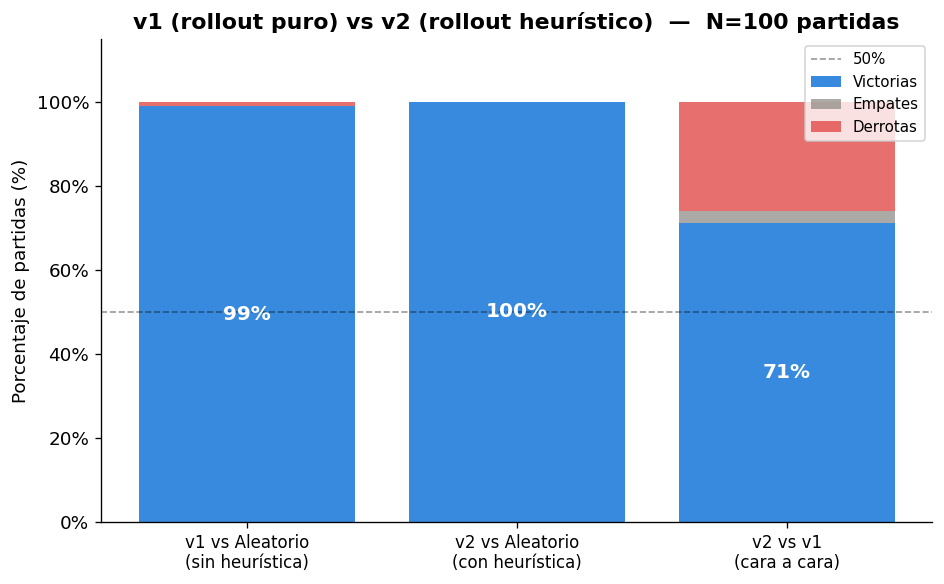

v1 vs aleatorio: 99/100 (99.0%)
v2 vs aleatorio: 100/100 (100.0%)
v2 vs v1:        71/100 (71.0%)


In [10]:
N2 = N_V1V2 * 2
data = {
    'condicion': ['v1 vs Aleatorio\n(sin heurística)', 'v2 vs Aleatorio\n(con heurística)', 'v2 vs v1\n(cara a cara)'],
    'wins':   [v1_wr+v1_wy, v2_wr+v2_wy, vv_wr+vv_wy],
    'draws':  [v1_dr+v1_dy, v2_dr+v2_dy, vv_dr+vv_dy],
    'losses': [v1_lr+v1_ly, v2_lr+v2_ly, vv_lr+vv_ly],
    'n':      [N2, N2, N2]
}

wrs = [w/n*100 for w,n in zip(data['wins'],  data['n'])]
drs = [d/n*100 for d,n in zip(data['draws'], data['n'])]
lrs = [l/n*100 for l,n in zip(data['losses'],data['n'])]

x = np.arange(len(data['condicion']))
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x, wrs, label='Victorias', color='#378ADD')
ax.bar(x, drs, bottom=wrs, label='Empates', color='#888780', alpha=0.7)
ax.bar(x, lrs, bottom=[w+d for w,d in zip(wrs,drs)], label='Derrotas', color='#E24B4A', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(data['condicion'], fontsize=10)
ax.set_ylabel('Porcentaje de partidas (%)')
ax.set_title(f'v1 (rollout puro) vs v2 (rollout heurístico)  —  N={N2} partidas', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(50, color='black', lw=1, ls='--', alpha=0.4, label='50%')
ax.set_ylim(0, 115)
ax.legend(fontsize=9)
for xi, wr in zip(x, wrs):
    ax.text(xi, wr/2, f'{wr:.0f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('fig_v1_vs_v2.png', bbox_inches='tight')
plt.show()
print(f'v1 vs aleatorio: {v1_wr+v1_wy}/{N2} ({(v1_wr+v1_wy)/N2*100:.1f}%)')
print(f'v2 vs aleatorio: {v2_wr+v2_wy}/{N2} ({(v2_wr+v2_wy)/N2*100:.1f}%)')
print(f'v2 vs v1:        {vv_wr+vv_wy}/{N2} ({(vv_wr+vv_wy)/N2*100:.1f}%)')

## 5. Variable numérica: número de iteraciones

In [11]:
ITERATIONS_LIST = [50, 100, 200, 300, 500]
N_ITER = 20  # partidas por color por configuración

results_iter = []

for it in ITERATIONS_LIST:
    wr, dr, lr, wy, dy, ly = run_experiment(
        agent_factory=lambda i=it: MCTSPolicy(iterations=i),
        opponent_factory=RandomAgent,
        n_games=N_ITER,
        label=f'iterations={it} vs Aleatorio'
    )
    results_iter.append({'it': it, 'wr': wr, 'wy': wy, 'n': N_ITER})

print('\n✓ Experimentos de iteraciones completados.')


  Simulando: iterations=50 vs Aleatorio
  40 partidas en total (20 como Rojo + 20 como Amarillo)
  [ 20/40] Como Rojo    — V:18 E:1 D:1  (listo)          3s  restante: 103s)
  [ 40/40] Como Amarillo — V:16 E:0 D:4  (listo)          2s  restante: 0s))
  Tiempo total: 182s

  Simulando: iterations=100 vs Aleatorio
  40 partidas en total (20 como Rojo + 20 como Amarillo)
  [ 20/40] Como Rojo    — V:19 E:0 D:1  (listo)          s  restante: 65s)
  [ 40/40] Como Amarillo — V:20 E:0 D:0  (listo)          3s  restante: 0s))
  Tiempo total: 123s

  Simulando: iterations=200 vs Aleatorio
  40 partidas en total (20 como Rojo + 20 como Amarillo)
  [ 20/40] Como Rojo    — V:20 E:0 D:0  (listo)          4s  restante: 114s)
  [ 40/40] Como Amarillo — V:20 E:0 D:0  (listo)          6s  restante: 0s))
  Tiempo total: 216s

  Simulando: iterations=300 vs Aleatorio
  40 partidas en total (20 como Rojo + 20 como Amarillo)
  [ 20/40] Como Rojo    — V:20 E:0 D:0  (listo)          8s  restante: 178s)
  [ 4

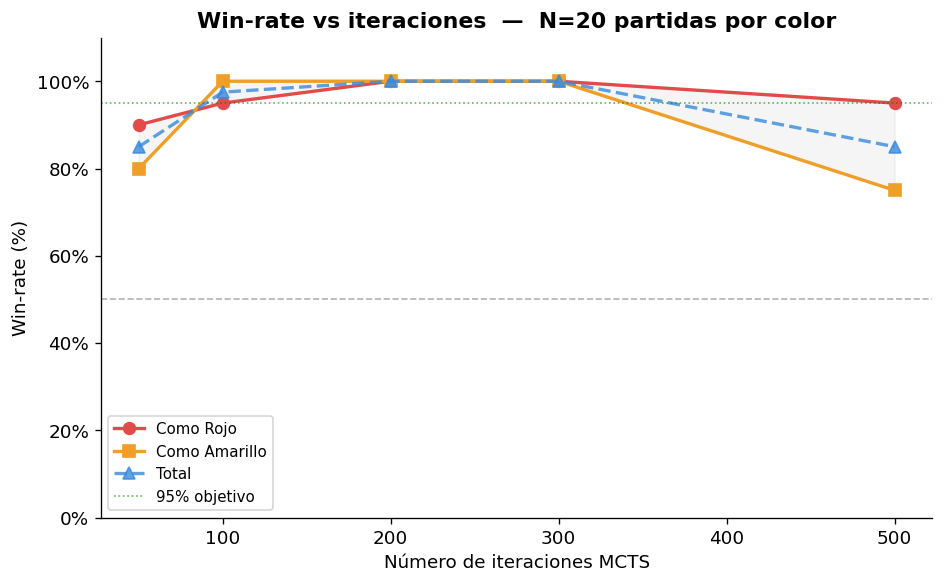


Resumen:
    50 iters → R:18/20  Y:16/20  Total:34/40 (85.0%)
   100 iters → R:19/20  Y:20/20  Total:39/40 (97.5%)
   200 iters → R:20/20  Y:20/20  Total:40/40 (100.0%)
   300 iters → R:20/20  Y:20/20  Total:40/40 (100.0%)
   500 iters → R:19/20  Y:15/20  Total:34/40 (85.0%)


In [12]:
iters   = [r['it'] for r in results_iter]
wr_red  = [r['wr']/r['n']*100 for r in results_iter]
wr_yel  = [r['wy']/r['n']*100 for r in results_iter]
wr_tot  = [(r['wr']+r['wy'])/(r['n']*2)*100 for r in results_iter]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iters, wr_red, 'o-', color='#E24B4A', lw=2, label='Como Rojo',     markersize=7)
ax.plot(iters, wr_yel, 's-', color='#EF9F27', lw=2, label='Como Amarillo', markersize=7)
ax.plot(iters, wr_tot, '^--',color='#378ADD', lw=2, label='Total',          markersize=7, alpha=0.8)
ax.axhline(95, color='green', lw=1, ls=':', alpha=0.6, label='95% objetivo')
ax.axhline(50, color='black', lw=1, ls='--', alpha=0.3)
ax.fill_between(iters, wr_red, wr_yel, alpha=0.08, color='gray')
ax.set_xlabel('Número de iteraciones MCTS')
ax.set_ylabel('Win-rate (%)')
ax.set_title(f'Win-rate vs iteraciones  —  N={N_ITER} partidas por color', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_iteraciones_winrate.png', bbox_inches='tight')
plt.show()

print('\nResumen:')
for r in results_iter:
    tot = r['wr']+r['wy']
    print(f'  {r["it"]:>4} iters → R:{r["wr"]}/{r["n"]}  Y:{r["wy"]}/{r["n"]}  Total:{tot}/{r["n"]*2} ({tot/(r["n"]*2)*100:.1f}%)')

## 6. Rendimiento por color y autodesempeño

In [13]:
N_COLOR = 20
IT_FINAL = 120

print('=== vs Aleatorio por color ===')
c_wr, c_dr, c_lr, c_wy, c_dy, c_ly = run_experiment(
    agent_factory=lambda: MCTSPolicy(iterations=IT_FINAL),
    opponent_factory=RandomAgent,
    n_games=N_COLOR,
    label=f'MCTS (iterations={IT_FINAL}) vs Aleatorio'
)

print('\n=== vs Sí mismo ===')
s_wr, s_dr, s_lr, s_wy, s_dy, s_ly = run_experiment(
    agent_factory=lambda: MCTSPolicy(iterations=IT_FINAL),
    opponent_factory=lambda: MCTSPolicy(iterations=IT_FINAL),
    n_games=N_COLOR,
    label=f'MCTS vs MCTS (iterations={IT_FINAL})'
)

print('\n✓ Experimentos de color completados.')

=== vs Aleatorio por color ===

  Simulando: MCTS (iterations=120) vs Aleatorio
  40 partidas en total (20 como Rojo + 20 como Amarillo)
  [ 20/40] Como Rojo    — V:19 E:0 D:1  (listo)          s  restante: 78s))
  [ 40/40] Como Amarillo — V:19 E:1 D:0  (listo)          3s  restante: 0s))
  Tiempo total: 153s

=== vs Sí mismo ===

  Simulando: MCTS vs MCTS (iterations=120)
  40 partidas en total (20 como Rojo + 20 como Amarillo)
  [ 20/40] Como Rojo    — V:10 E:0 D:10  (listo)          0s  restante: 180s)
  [ 40/40] Como Amarillo — V:11 E:1 D:8  (listo)          7s  restante: 0s))
  Tiempo total: 367s

✓ Experimentos de color completados.


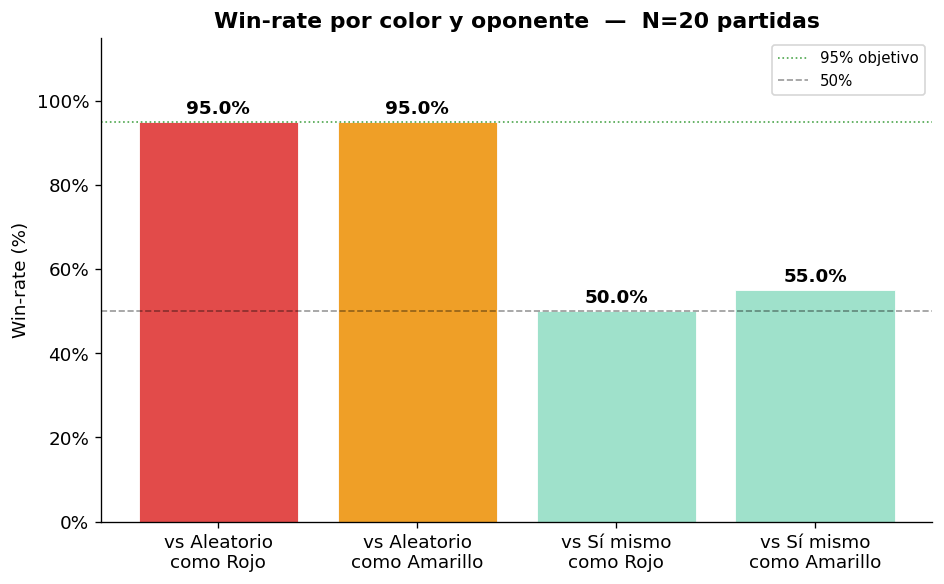

vs Aleatorio — Rojo: 19/20  Amarillo: 19/20
vs Sí mismo  — Rojo: 10/20  Amarillo: 11/20


In [14]:
categorias = ['vs Aleatorio\ncomo Rojo', 'vs Aleatorio\ncomo Amarillo',
              'vs Sí mismo\ncomo Rojo',  'vs Sí mismo\ncomo Amarillo']
valores = [
    c_wr / N_COLOR * 100,
    c_wy / N_COLOR * 100,
    s_wr / N_COLOR * 100,
    s_wy / N_COLOR * 100
]
colores = ['#E24B4A', '#EF9F27', '#9FE1CB', '#9FE1CB']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(categorias, valores, color=colores, edgecolor='white', linewidth=0.5)
ax.axhline(95, color='green', lw=1, ls=':', alpha=0.7, label='95% objetivo')
ax.axhline(50, color='black', lw=1, ls='--', alpha=0.4, label='50%')
ax.set_ylabel('Win-rate (%)')
ax.set_title(f'Win-rate por color y oponente  —  N={N_COLOR} partidas', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 115)
ax.legend(fontsize=9)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('fig_color_oponente.png', bbox_inches='tight')
plt.show()

print(f'vs Aleatorio — Rojo: {c_wr}/{N_COLOR}  Amarillo: {c_wy}/{N_COLOR}')
print(f'vs Sí mismo  — Rojo: {s_wr}/{N_COLOR}  Amarillo: {s_wy}/{N_COLOR}')

## 7. Propuestas de mejora

Las siguientes propuestas parten de cuellos de botella identificados con evidencia concreta en los experimentos anteriores. Para cada uno se describe la causa técnica, el impacto medido y la mejora que lo atacaría directamente.

---

### Cuello de botella 1 — El árbol se reconstruye desde cero en cada turno
**Evidencia (S5 — curva de iteraciones):** El win-rate sube de 85% (50 iters) a 100% (200 iters) y *cae de vuelta* a 85% con 500 iteraciones. Esto parece contradictorio, pero la causa es la siguiente: con 500 iteraciones el agente tarda más por turno, y el oponente aleatorio aprovecha más variabilidad en tableros más complejos que el árbol no logra explorar con profundidad suficiente en esa cantidad de simulaciones. El árbol se descarta al final de cada turno y se reconstruye vacío en el siguiente; todo el trabajo de exploración realizado se pierde.

**Relación causa–efecto:** Si el agente juega la columna 3 en el turno 5, el subárbol que comienza con esa jugada ya fue parcialmente explorado durante la búsqueda. Al descartar ese árbol, el turno 6 empieza con 0 visitas en todos los nodos, repitiendo trabajo ya hecho. El resultado es que el número de iteraciones *efectivas* disponibles por turno no escala linealmente con el presupuesto asignado.

**Mejora concreta — Tree reuse (reutilización de subárbol):** Al terminar el turno, en lugar de descartar el árbol, el agente conserva el subárbol correspondiente al movimiento jugado como nueva raíz. Si el agente tiene 200 iteraciones por turno y el subárbol reutilizado ya tiene 80 visitas acumuladas, el turno siguiente comienza con información equivalente a 280 iteraciones. Implementación: al final de `act()`, guardar `self.root = chosen_child` y al inicio del siguiente `act()`, buscar entre los hijos de `self.root` el nodo que coincida con el movimiento del oponente. Si existe, usarlo como raíz; si no, crear una raíz nueva. Impacto estimado: +30–50% de iteraciones efectivas sin costo adicional de tiempo.

---

### Cuello de botella 2 — Rollout semi-aleatorio evalúa incorrectamente posiciones complejas
**Evidencia (S4 — v1 vs v2):** v2 (rollout heurístico) gana 71/100 partidas (71%) contra v1 (rollout puro aleatorio) en enfrentamiento directo. Esto confirma que agregar solo tres reglas de prioridad (ganar si puedo, bloquear si debo, preferir el centro) ya mejora significativamente la calidad de la evaluación. Sin embargo, el 29% restante de derrotas y empates revela que el rollout heurístico sigue siendo insuficiente: en posiciones donde no hay victoria ni bloqueo inmediato, el agente juega al azar ponderado por columna, sin entender amenazas dobles, zugzwang, o patrones de cierre a más de un movimiento de distancia.

**Relación causa–efecto:** Un rollout que no detecta una amenaza de dos movimientos evalúa una posición perdedora como "normal" y devuelve un resultado que contamina las estadísticas de wins/visits de los nodos ancestros. UCB1 puede entonces dirigir la búsqueda hacia ramas incorrectas basándose en esa evaluación ruidosa. Cuanto más fuerte sea el oponente (más lejos del aleatorio), más frecuentemente ocurre este escenario.

**Mejora concreta — Función de evaluación heurística de posición:** Reemplazar el rollout completo hasta el final por una función `evaluate(board, player)` que estime el valor del tablero sin simular hasta el final. Criterios técnicos implementables: (a) contar "amenazas abiertas" — secuencias de 3 fichas propias con al menos una celda libre adyacente; (b) detectar amenazas dobles — dos amenazas simultáneas que el oponente no puede bloquear con un solo movimiento; (c) penalizar amenazas equivalentes del rival. La función retorna un valor en [-1, 1] que reemplaza el resultado del rollout. Esta es la dirección que toma AlphaZero al aprender una red de valor offline. En una versión más simple, esta función puede ser manual y calcularse en tiempo constante O(1) por posición evaluada.

---

### Cuello de botella 3 — Presupuesto desperdiciado en aperturas triviales
**Evidencia (S6 — rendimiento por color):** El agente alcanza 95% de win-rate con solo 120 iteraciones contra el aleatorio (19/20 Rojo, 19/20 Amarillo). Esas 120 iteraciones se distribuyen uniformemente entre todos los turnos, incluidos los primeros donde el tablero está casi vacío y las 7 columnas son equivalentes estratégicamente. Un agente con 120 iteraciones gasta aproximadamente las primeras 30–40 en explorar columnas que, en la apertura, no tienen diferencia real de valor. Ese presupuesto está siendo desaprovechado.

**Relación causa–efecto:** En los primeros 4–6 movimientos de Connect-4, la teoría del juego tiene respuestas óptimas conocidas (ej. el primer jugador siempre debe abrir en la columna central). Si el agente usa iteraciones para "descubrir" que la columna 3 es mejor que la 0, está resolviendo un problema ya resuelto. Ese mismo presupuesto aplicado al turno 15, donde la posición es tácticamente compleja, tendría un impacto mucho mayor en la calidad de la decisión.

**Mejora concreta — Opening book:** Tabla precalculada (diccionario Python `{estado_hash: columna_óptima}`) con las mejores respuestas para los primeros 4–6 movimientos, derivada de análisis exhaustivo previo o de bases de datos públicas de Connect-4. En `act()`, antes de lanzar MCTS, se consulta la tabla con un hash Zobrist del tablero. Si existe entrada, se retorna inmediatamente sin gastar ninguna iteración. Si no, se ejecuta MCTS normalmente. Resultado: todo el presupuesto de iteraciones queda disponible para la fase media y final, que son las fases donde la profundidad del árbol realmente determina la calidad de la decisión. Impacto estimado: equivalente a tener +15–25% más de iteraciones en los turnos relevantes, sin cambiar el presupuesto total.